In [3]:
from style_encoder_train import IAMDataset_style
from utils.auxilary_functions import affine_transformation
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from feature_extractor import ImageEncoder
import torch

In [ ]:
dataset_folder = '/extra_space2/oles_new/iam_data'
aug_transforms = [lambda x: affine_transformation(x, s=.1)]

train_transform = transforms.Compose([
                    #transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #transforms.Normalize((0.5,), (0.5,)),  #
                    ])

val_transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #transforms.Normalize((0.5,), (0.5,)),  #
                    ])

train_data = IAMDataset_style(dataset_folder, 'train', 'word', fixed_size=(1 * 64, 256), transforms=train_transform)

save_file ./IAM_dataset_PIL_style/train_word_IAM.pt
root_path /extra_space2/oles_new/iam_data/words


/home/oles/DiffusionPen/style_encoder_train.py:609: UserWarning: Input line 864 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  valid_set = np.loadtxt('./utils/aachen_iam_split/train_val.uttlist', dtype=str)


imgs: [0/55558 (0%)]
imgs: [1000/55558 (2%)]
imgs: [2000/55558 (4%)]
imgs: [3000/55558 (5%)]
imgs: [4000/55558 (7%)]
imgs: [5000/55558 (9%)]
imgs: [6000/55558 (11%)]
imgs: [7000/55558 (13%)]
imgs: [8000/55558 (14%)]
imgs: [9000/55558 (16%)]
imgs: [10000/55558 (18%)]
imgs: [11000/55558 (20%)]
imgs: [12000/55558 (22%)]
imgs: [13000/55558 (23%)]
imgs: [14000/55558 (25%)]
imgs: [15000/55558 (27%)]
imgs: [16000/55558 (29%)]
imgs: [17000/55558 (31%)]
imgs: [18000/55558 (32%)]
imgs: [19000/55558 (34%)]
imgs: [20000/55558 (36%)]
imgs: [21000/55558 (38%)]
imgs: [22000/55558 (40%)]
imgs: [23000/55558 (41%)]
imgs: [24000/55558 (43%)]
imgs: [25000/55558 (45%)]
imgs: [26000/55558 (47%)]
imgs: [27000/55558 (49%)]
imgs: [28000/55558 (50%)]
imgs: [29000/55558 (52%)]
imgs: [30000/55558 (54%)]
imgs: [31000/55558 (56%)]
imgs: [32000/55558 (58%)]
imgs: [33000/55558 (59%)]
imgs: [34000/55558 (61%)]
imgs: [35000/55558 (63%)]
imgs: [36000/55558 (65%)]
imgs: [37000/55558 (67%)]
imgs: [38000/55558 (68%)]
imgs:

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 55554/55554 [00:00<00:00, 1546012.49it/s]

Character classes: ['!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' '] (79 different characters)
Max transcription length: 19


In [57]:
train_loader = DataLoader(train_data, batch_size=20, shuffle=True, num_workers=4)

In [58]:
style_classes = 339

In [59]:
data = next(iter(train_loader))
anchor = data[0]
el = el.to(device)

positive = data[3]
negative = data[4]

In [60]:
positive

tensor([311,  55,  71,  54,  31,  93, 156,  25, 228,  95,   1, 103, 332,  14,
        129,  43, 293,  57, 337, 101])

In [61]:
negative.size()

torch.Size([20, 3, 64, 256])

In [62]:
model = ImageEncoder(model_name='mobilenetv2_100', num_classes=style_classes, pretrained=True, trainable=True)

In [63]:
device = "cuda:0"

In [71]:
model = model.to(device)

In [72]:
model(el)

tensor([[ 0.7737,  0.1273, -0.1422,  ..., -0.0182, -1.5180,  0.7465],
        [-1.3769,  0.1797,  0.6029,  ..., -1.3167, -1.4502,  0.2298],
        [-0.5037, -1.0210, -0.1568,  ..., -1.1010, -0.7254, -0.5681],
        ...,
        [ 0.6129,  0.2440, -0.9258,  ...,  0.2860, -1.6223,  0.5871],
        [-0.0559, -0.2343,  1.0015,  ..., -3.4197, -0.8726, -1.4180],
        [ 1.3567, -0.2803,  1.4313,  ..., -1.8570, -0.4486,  1.3586]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
index = 26495

img = train_data.data[index][0]
print(img)

transcr = train_data.data[index][1]

wid = train_data.data[index][2]

img_path = train_data.data[index][3]

nwidth = int(np.random.uniform(.75, 1.25) * img.width)
nheight = int((np.random.uniform(.9, 1.1) * img.height / img.width) * nwidth)

fheight, fwidth = train_data.fixed_size[0], train_data.fixed_size[1]

nheight, nwidth = max(4, min(fheight-16, nheight)), max(8, min(fwidth-32, nwidth))

if img.width < 256:
    img = ImageOps.pad(img, size=(256, 64), color= "white")#, centering=(0,0)) uncommment to pad right
pixel_values_img = img #self.processor(img, return_tensors="pt").pixel_values
pixel_values_img = pixel_values_img#.squeeze(0)
print(index, img)

<PIL.Image.Image image mode=RGB size=262x71 at 0x7C2A425E7EC0>
26495 <PIL.Image.Image image mode=RGB size=262x71 at 0x7C2A425E7EC0>


In [74]:
model = ImageEncoder(model_name='mobilenetv2_100', num_classes=style_classes, pretrained=True, trainable=True)

In [ ]:
device = "cuda:0"
PATH = "./style_models/triplet_iam_mobilenetv2_100.pth"
state_dict = torch.load(PATH, map_location=device)
model_dict = model.state_dict()e
state_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(state_dict)
model.load_state_dict(model_dict)

<All keys matched successfully>

In [69]:
print(len(train_data[0]))
img, _, _, _, _, _, _, _, _, _, _, _  = train_data[0]

12


In [80]:
type(img)

PIL.Image.Image

In [116]:
model.eval()
model = model.to(device)
train_loader = DataLoader(train_data, batch_size=20, shuffle=False, num_workers=4)
first_batch = next(iter(train_loader))
first_element = first_batch[0]
img = first_element[1]
embedding = model(img.unsqueeze(0).to(device))

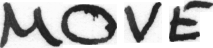

In [117]:
train_data.data[1][0]

In [130]:
train_loader = DataLoader(train_data, batch_size=100, shuffle=False, num_workers=4)
model.eval()
model = model.to(device)
all_embeddings = []
all_indices = []

with torch.no_grad():
    for i, batch in enumerate(tqdm(train_loader)):
        imgs = batch[0].to(device)
        emb = model(imgs)
        all_embeddings.append(emb.cpu())
        all_indices.extend(range(i * len(imgs), i * len(imgs) + len(imgs)))
all_embeddings = torch.cat(all_embeddings, dim=0)
distances = torch.cdist(embedding.cpu(), all_embeddings, p=2).squeeze(0)

100%|█████████████████████████████████████████| 556/556 [03:32<00:00,  2.61it/s]


In [131]:
topk = torch.topk(-distances, k=10)   # negate to get smallest
topk_indices = topk.indices.tolist()
topk_values = distances[topk_indices].tolist()

12


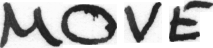

12


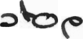

12


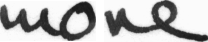

12


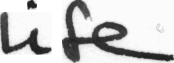

71


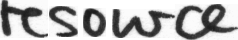

12


12


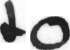

12


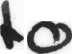

12


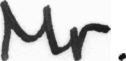

12


In [133]:
from IPython.display import display

for index in topk_indices:
    print(train_data.data[index][2])
    img = train_data.data[index][0]
    display(img)

In [1]:
import numpy as np

In [3]:
valid_set = np.loadtxt('./utils/hkr_split/train_fixed.uttlist', dtype=str)

ValueError: the number of columns changed from 4 to 5 at row 3; use `usecols` to select a subset and avoid this error